In [1]:
#import relevant libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from collections import defaultdict
from matplotlib.patches import Ellipse

warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# File processing
homecomp = "D:"
filepath = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Together\\3. Compiled\\"
openPath = homecomp + filepath
files2 = os.listdir(openPath)
files2

['46416jus x ACR [ATR] allstats.csv',
 '46416jus x eOPN3 allstats.csv',
 '46416jus x eOPN3-TS-ER allstats.csv',
 'Cha-6793 x eOPN3 allstats.csv',
 'Cha-6793 x eOPN3-TS-ER allstats.csv',
 'ChAT;GCamp x eOPN3 allstats.csv',
 'elav x ACR [ATR] allstats.csv',
 'elav x eOPN3 allstats.csv',
 'elav x eOPN3-TS-ER allstats.csv',
 'nSyb x ACR allstats.csv',
 'nSyb x eOPN3 allstats.csv',
 'nSyb x eOPN3-TS-ER(iii)M1 allstats.csv',
 'nSyb x eOPN3-TS-ER(iii)M2 allstats.csv',
 'nSyb x eOPN3-TS-ER(iii)M4 allstats.csv',
 'nSyb x eOPN3-TS-ER(iii)M5 allstats.csv',
 'OK371 x ACR allstats.csv',
 'OK371 x eOPN3 allstats.csv',
 'OK371 x eOPN3;Gai allstats.csv',
 'OK371 x eOPN3;Gao allstats.csv',
 'Piezo x ACR allstats.csv',
 'Piezo x eOPN3 allstats.csv',
 'Piezo x eOPN3;Gai allstats.csv',
 'Piezo x eOPN3;Gao allstats.csv',
 'Repo x ACR allstats.csv',
 'Repo x eOPN3 allstats.csv',
 'vGAT x eOPN3 allstats.csv',
 'vGAT x eOPN3-TS-ER allstats.csv',
 'vGAT(v) x eOPN3-TS-ER allstats.csv',
 'vGlut x eOPN3 allstats.

In [6]:
files3 = ['nSyb x eOPN3 allstats.csv','nSyb x eOPN3-TS-ER(iii)M4 allstats.csv', 
          '46416jus x eOPN3 allstats.csv', '46416jus x eOPN3-TS-ER allstats.csv',
          'Cha-6793 x eOPN3 allstats.csv', 'Cha-6793 x eOPN3-TS-ER allstats.csv',
 'elav x eOPN3 allstats.csv', 'elav x eOPN3-TS-ER allstats.csv',
 'vGAT x eOPN3 allstats.csv', 'vGAT x eOPN3-TS-ER allstats.csv'
]

# files3 = ['46146jus x ACR[ATR] allstats.csv',
#  '46146jus x eOPN3 allstats.csv',
#  '46146jus x eOPN3[ATR] allstats.csv',
#  'elav x ACR allstats.csv',
#  'elav x eOPN3 allstats.csv'

# ]

# files3 = ['Cha x eOPN3 allstats.csv',
#  'vGAT x eOPN3 allstats.csv', 
# 'nsyb x eOPN3 allstats.csv'
# ]

# files3 = ['OK371 x ACR allstats.csv',
#  'OK371 x eOPN3 allstats.csv',
#  'OK371 x eOPN3-galphai allstats.csv',
#  'OK371 x eOPN3-galphao allstats.csv'
#  ]


# files3 = ['Piezo x ACR allstats.csv',
#  'Piezo x eOPN3 allstats.csv',
#  'Piezo x eOPN3-galphai allstats.csv',
#  'Piezo x eOPN3-galphao allstats.csv']


# files3 = ['nsyb x eOPN3 allstats.csv',
#  'nsyb x PdCO [B] allstats.csv',
#   'Cha x eOPN3 allstats.csv',
#  'Cha x PdCO allstats.csv',]

In [15]:
def pergenotypeplotting(openPath, files2, k): 
    metricname = pd.DataFrame()
    singlemeandiff = pd.DataFrame()
    
    for f in files2:
        newfile2read = pd.read_csv(openPath + f, index_col=0)
        cross = f.replace(" allstats.csv", "").replace("[ATR]", "*").replace("eOPN3", "AsOPN3").replace("[B]", "").replace("(iii)M4", "")
        
        # Create dataframes directly in one step
        samplefile = pd.DataFrame({
            'bootstrap': newfile2read[k+"_bootstrap"],
            'deltag': newfile2read[k+"_deltag"],
            'Cross': cross,
            'metric': k
        })
        
        singlemeans = pd.DataFrame({
            'mean': samplefile['deltag'].unique(),
            'cross': cross,
            'err': samplefile['bootstrap'].mean() - (samplefile['bootstrap'].mean() - 1.96*(np.std(samplefile['bootstrap'])))
        })

        metricname = pd.concat([metricname, samplefile], axis=0)
        singlemeandiff = pd.concat([singlemeandiff, singlemeans], axis=0)

    return metricname, singlemeandiff

def forestplot(metricname, singlemeandiff, gridkey):
    import textwrap
    # Setup
    fig = plt.figure(figsize=(8, 5))
    unique_crosses = singlemeandiff['cross'].unique()
    n_crosses = len(unique_crosses)
    padding = 0.7
    violin_color = "#3C9A29"
    
    # Create subplots
    ax_main = plt.subplot2grid((6, 1), (0, 0), rowspan=4)
    ax_table = plt.subplot2grid((6, 1), (4, 0), rowspan=1, sharex=ax_main)
    
    # Extract drivers and responders
    drivers = [cross.split(' ')[0] for cross in unique_crosses]
    responders = [cross.split(' ')[-1] for cross in unique_crosses]
    
    # Main plot: Create violin plots and error bars
    for i, (cross, mean, err) in enumerate(zip(singlemeandiff['cross'], singlemeandiff['mean'], singlemeandiff['err'])):
        # Violin plot
        cross_data = metricname[metricname['Cross'] == cross]['bootstrap']
        parts = ax_main.violinplot([cross_data], positions=[i], widths=0.6, 
                                 showmeans=False, showmedians=False, showextrema=False)
        
        # Style violin as right half only
        for pc in parts['bodies']:
            pc.set_facecolor(violin_color)
            pc.set_alpha(0.85)
            pc.set_edgecolor('none')
            vertices = pc.get_paths()[0].vertices
            vertices[:, 0] = np.maximum(vertices[:, 0], i)
        
        # Error bar and text
        ax_main.errorbar(i, mean, yerr=err, fmt='o', color='black', markersize=6, 
                        capsize=0, capthick=0, elinewidth=2)
        ax_main.text(i - 0.1, mean, f'{mean:.2f}', ha='right', va='center', 
                    fontsize=10, color=violin_color, fontweight='bold')
    
    # Format main plot
    ax_main.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax_main.set_ylabel("Δg of " + metricname['metric'].unique()[0], fontsize=12)
    ax_main.set_ylim(-4.5, 1.2)
    ax_main.set_xlim(-padding, n_crosses - 1 + padding)
    ax_main.grid(False)
    for spine in ['top', 'right', 'bottom']:
        ax_main.spines[spine].set_visible(False)
    ax_main.set_xticks([])
    ax_main.set_xticklabels([])
    
    # Format table subplot
    ax_table.set_ylim(0, 1)
    gridkeylabel = textwrap.fill(gridkey, width=7)
    ax_table.set_ylabel(gridkeylabel, fontsize = 10, style = 'italic', labelpad = 15, rotation = 0, loc ='center')
    for spine in ax_table.spines.values():
        spine.set_visible(False)
    ax_table.set_xticks([])
    ax_table.set_yticks([])
    
    # Draw grid
    first_grid, last_grid = -0.5, n_crosses - 0.5
    x_range = n_crosses - 1 + 2*padding
    
    # Horizontal lines
    for y in [0.2, 0.8]:
        ax_table.axhline(y=y, color='black', linewidth=1, 
                        xmin=(first_grid + padding) / x_range, 
                        xmax=(last_grid + padding) / x_range)
    
    # Vertical lines
    for i in range(n_crosses + 1):
        ax_table.axvline(x=i - 0.5, color='black', linewidth=1, ymin=0.2, ymax=0.8)
    
    # Add circles
    bbox = ax_table.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    radius_x = (10 / 72.0) / bbox.width * x_range / 2
    radius_y = (10 / 72.0) / bbox.height / 2
    
    for i, responder in enumerate(responders):
        if responder == gridkey:
            circle = Ellipse((i, 0.5), width=2*radius_x, height=2*radius_y, 
                           color='black', clip_on=False)
            ax_table.add_patch(circle)
    
    # Driver labels
    driver_groups = defaultdict(list)
    for i, driver in enumerate(drivers):
        driver_groups[driver].append(i)
    
    for driver, indices in driver_groups.items():
        if len(indices) > 1:
            x_start, x_end = min(indices) - 0.3, max(indices) + 0.3
            ax_table.plot([x_start, x_end], [0.05, 0.05], 'k-', linewidth=1)
            ax_table.text((x_start + x_end) / 2, -0.05, driver, ha='center', va='top', 
                         fontsize=10, style='italic')
    
    return fig

# TS-ER

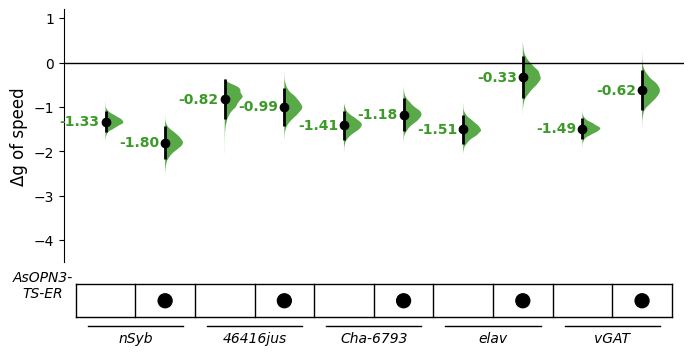

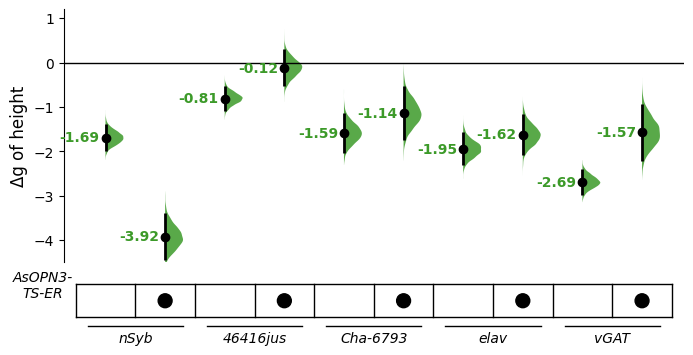

In [16]:
# Generate plots
lstnamings = ['speed', 'height']

for n in lstnamings:
    dfmn, dfsmd = pergenotypeplotting(openPath, files3, n)
    g = forestplot(dfmn, dfsmd, "AsOPN3-TS-ER")
    #g.savefig(titledpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data Compilation\\Together\\images\\forestplot of TS_ER " + n + ".svg", bbox_inches="tight") 
    plt.show()

# ACR or eOPN3


In [40]:
def pergenotypeplotting(openPath, files2, k): 
    metricname = pd.DataFrame()
    singlemeandiff = pd.DataFrame()
    
    for f in files2:
        newfile2read = pd.read_csv(openPath + f, index_col=0)
        cross = f.replace(" allstats.csv", "").replace("[ATR]", "*").replace("eOPN3", "AsOPN3").replace("[B]", "").replace("(iii)M4", "")
        
        # Create dataframes directly in one step
        samplefile = pd.DataFrame({
            'bootstrap': newfile2read[k+"_bootstrap"],
            'deltag': newfile2read[k+"_deltag"],
            'Cross': cross,
            'metric': k
        })
        
        singlemeans = pd.DataFrame({
            'mean': samplefile['deltag'].unique(),
            'cross': cross,
            'err': samplefile['bootstrap'].mean() - (samplefile['bootstrap'].mean() - 1.96*(np.std(samplefile['bootstrap'])))
        })

        metricname = pd.concat([metricname, samplefile], axis=0)
        singlemeandiff = pd.concat([singlemeandiff, singlemeans], axis=0)

    return metricname, singlemeandiff

def forestplot_specific(metricname, singlemeandiff, gridkey1, gridkey2):
    import textwrap
    # Setup
    fig = plt.figure(figsize=(8, 5))
    unique_crosses = singlemeandiff['cross'].unique()
    n_crosses = len(unique_crosses)
    padding = 0.7
    violin_color = "#3C9A29"
    
    # Create subplots
    ax_main = plt.subplot2grid((6, 1), (0, 0), rowspan=4)
    ax_table = plt.subplot2grid((6, 1), (4, 0), rowspan=2, sharex=ax_main)
    
    # Extract drivers and responders
    drivers = [cross.split(' ')[0] for cross in unique_crosses]
    responders = [cross.split(' ')[-1] for cross in unique_crosses]
    
    # Main plot: Create violin plots and error bars
    for i, (cross, mean, err) in enumerate(zip(singlemeandiff['cross'], singlemeandiff['mean'], singlemeandiff['err'])):
        # Violin plot
        cross_data = metricname[metricname['Cross'] == cross]['bootstrap']
        parts = ax_main.violinplot([cross_data], positions=[i], widths=0.6, 
                                 showmeans=False, showmedians=False, showextrema=False)
        
        # Style violin as right half only
        for pc in parts['bodies']:
            pc.set_facecolor(violin_color)
            pc.set_alpha(0.85)
            pc.set_edgecolor('none')
            vertices = pc.get_paths()[0].vertices
            vertices[:, 0] = np.maximum(vertices[:, 0], i)
        
        # Error bar and text
        ax_main.errorbar(i, mean, yerr=err, fmt='o', color='black', markersize=6, 
                        capsize=0, capthick=0, elinewidth=2)
        ax_main.text(i - 0.1, mean, f'{mean:.2f}', ha='right', va='center', 
                    fontsize=10, color=violin_color, fontweight='bold')
    
    # Format main plot
    ax_main.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax_main.set_ylabel("Δg of " + metricname['metric'].unique()[0], fontsize=12)
    ax_main.set_ylim(-4.5, 1.2)
    ax_main.set_xlim(-padding, n_crosses - 1 + padding)
    ax_main.grid(False)
    for spine in ['top', 'right', 'bottom']:
        ax_main.spines[spine].set_visible(False)
    ax_main.set_xticks([])
    ax_main.set_xticklabels([])
    
    # Format table subplot
    ax_table.set_ylim(0, 1)
      
    for spine in ax_table.spines.values():
        spine.set_visible(False)
    ax_table.set_xticks([])
    ax_table.set_yticks([])
    
    # Draw grid
    first_grid, last_grid = -0.5, n_crosses - 0.5
    x_range = n_crosses - 1 + 2*padding
    
    # Horizontal lines
    for y in [0.2, 0.5, 0.8]:
        ax_table.axhline(y=y, color='black', linewidth=1, 
                        xmin=(first_grid + padding) / x_range, 
                        xmax=(last_grid + padding) / x_range)
    
    # Vertical lines
    for i in range(n_crosses + 1):
        ax_table.axvline(x=i - 0.5, color='black', linewidth=1, ymin=0.2, ymax=0.8)
    
    # Add circles
    bbox = ax_table.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    radius_x = (10 / 72.0) / bbox.width * x_range / 2
    radius_y = (10 / 72.0) / bbox.height / 2
    
    # Handling tables based on gridkey genotypes
    gridkeylabel1 = textwrap.fill(gridkey1, width=7)
    ax_table.text(-1.5, 0.35, gridkeylabel1, fontsize = 10, style = 'italic')
    
    gridkeylabel2 = textwrap.fill(gridkey2, width=7)
    ax_table.text(-1.5, 0.65, gridkeylabel2, fontsize = 10, style = 'italic')
    
    for i, responder in enumerate(responders):
        if responder in gridkey1:
            circle = Ellipse((i, 0.35), width=2*radius_x, height=2*radius_y, 
                           color='black', clip_on=False)
            ax_table.add_patch(circle)
        else:  #cannot use for AsOPN3_TS_ER
            circle = Ellipse((i, 0.65), width=2*radius_x, height=2*radius_y, 
                           color='black', clip_on=False)
            ax_table.add_patch(circle)
    
    # Driver labels
    driver_groups = defaultdict(list)
    for i, driver in enumerate(drivers):
        driver_groups[driver].append(i)
    
    for driver, indices in driver_groups.items():
        x_start, x_end = min(indices) - 0.3, max(indices) + 0.3
        ax_table.plot([x_start, x_end], [0.05, 0.05], 'k-', linewidth=1)
        ax_table.text((x_start + x_end) / 2, -0.05, driver, ha='center', va='top', 
                        fontsize=10, style='italic')

            
            
    return fig

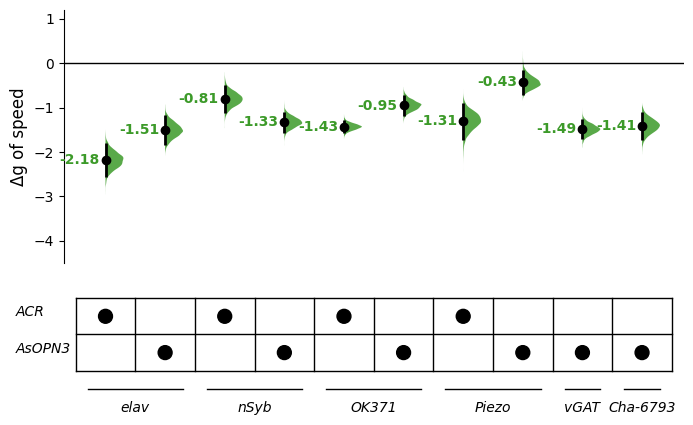

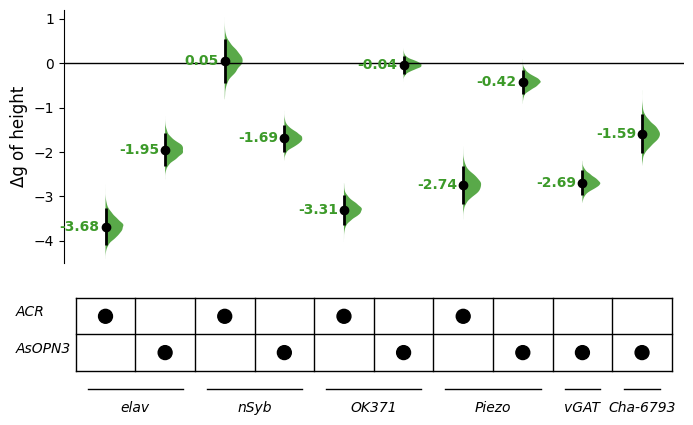

In [41]:
# Generate plots

files4 = ['elav x ACR [ATR] allstats.csv',  'elav x eOPN3 allstats.csv',           
          'nSyb x ACR allstats.csv', 'nSyb x eOPN3 allstats.csv',
          'OK371 x ACR allstats.csv', 'OK371 x eOPN3 allstats.csv', 
          'Piezo x ACR allstats.csv', 'Piezo x eOPN3 allstats.csv', 
          'vGAT x eOPN3 allstats.csv', 'Cha-6793 x eOPN3 allstats.csv']

lstnamings = ['speed', 'height']

for n in lstnamings:
    dfmn, dfsmd = pergenotypeplotting(openPath, files4, n)
    g = forestplot_specific(dfmn, dfsmd, "AsOPN3", "ACR")
    #g.savefig(titledpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data Compilation\\Together\\images\\forestplot of TS_ER " + n + ".svg", bbox_inches="tight") 
    plt.show()